# Entropy of degree distribution

### Imports

In [2]:
from __future__ import annotations
import networkx as nx
import pytest
from abc import ABC, abstractmethod
import numpy as np
import math

### Error Classes

In [3]:
class NormalizationError(Exception):
    """Exception raised for errors in the normalization.

    Attributes:
        message -- explanation of the error
    """

    def __init__(self, message="An error occurred during normalization."):
        self.message = message
        super().__init__(self.message)

class NullGraphError(Exception):
    """Exception raised for null graph."""
    pass

class EmptyGraphError(Exception):
    """Exception raised for empty graph. Nodes with no edges."""
    pass


def check_raw_value(func):
    """Decorator to check if raw value is None. If it is, raise an error."""
    def wrapper(self, *args):
        if self._raw_value is not None:
            return func(self, *args)
        else:
            raise ValueError("Raw value is None. Call compute() method first.")
    return wrapper

### Abstract Class

In [4]:
class _Property(ABC):
    """Abstract base class for all properties."""
    _return_type = None
    _use_paths = False
    _use_direction = False
    _use_selfloops = False
    _use_giant_component = False

    def __init__(self, G: nx.DiGraph):
        self.G = G
        self._raw_value = None
        self._n_nodes = self.G.number_of_nodes()
        if self._n_nodes == 0:
            raise NullGraphError("Can not calculate subgraph centrality for inexistent nodes.")

    @abstractmethod
    def compute(self):
        return self._raw_value

    @abstractmethod
    def norm_biol(self, *args):
        pass

    @abstractmethod
    def norm_network(self, *args):
        pass

### Decorators

In [5]:
def use_direction(cls):
    cls._use_direction = True
    return cls

def use_selfloops(cls):
    cls._use_selfloops = True
    return cls

def use_giant_component(cls):
    cls._use_giant_component = True
    return cls

def return_scalar(cls):
    cls._return_type = "scalar"
    return cls

def return_distribution(cls):
    cls._return_type = "distribution"
    return cls

def use_paths(cls):
    cls._use_paths = True
    return cls

### Auxiliar Fxns
Fxn que calcula la entropia de cualquier arreglo de elementos

In [88]:
def get_entropy(elements: np.array):
    """Get the entropy of an array of elements."""
    entropy = ((elements * np.log2(elements)).sum())
    return entropy if entropy == 0 else -entropy

### Entropy Class
Entropy describes how much randomness is present in a signal or a random event.

The entropy of the degree distribution provides a measurement of the heterogeneity of the network. Where the maximun value of entropy is obtained for a uniform degree distribution and the minimun value of 0 is obtained whenever all vertices have the same degree.

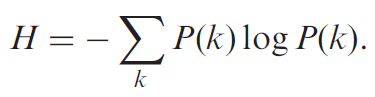

In [77]:
@return_scalar 
@use_direction
@use_selfloops  
class EntropyPKout(_Property):
    """Entropy of degree distribution.

    Entropy of the degree distribution is defined as the absolute valueof the sum of each probability to have a certain degree
    multiplied by its own log2.

    Methods:
        compute: Compute the entropy of the degree distribution for a graph.
        norm_biol: Normalize the entropy of the degree distribution to the max theoretical value.
        norm_network: Normalize the entropy of the degree of distribution to the max theoretical value.
    """

    def __init__(self, G: nx.DiGraph):
        """
        Args:
            G (nx.DiGraph): Graph.
        """
        super().__init__(G)

    def compute(self) -> float:
        """Compute the entropy for the degree distribution of the graph.

        Returns:
            float: entropy of the degree distribution.    
        """
        
        degrees = np.array([x for a,x in self.G.out_degree()])
        uniques, counts = np.unique(degrees, return_counts=True)
        
        #Frequencies are only determined to degrees existent in the network, degrees with a frequency of 0 are ignored
        freq = counts * (1 / self._n_nodes)
        self._raw_value = get_entropy(freq)
        
        self.h_max = math.log2(self._n_nodes)
        
        return self._raw_value

    @check_raw_value
    def norm_biol(self) -> float:
        """Normalize the entropy of the degree distribution to the max theoretical entropy."""
        return self._raw_value / self.h_max

    @check_raw_value
    def norm_network(self) -> float:
        """Normalize the entropy of the degree distribution to the max theoretical entropy"""
        return self._raw_value / self.h_max 

### Testing

In [90]:
# Null graph
G = nx.DiGraph()
with pytest.raises(NullGraphError) as e_info:
    property = EntropyPKout(G)

# Empty graph
n_nodes= 5
G.add_nodes_from(range(n_nodes))
property = EntropyPKout(G)
assert property.compute() == 0
assert property.norm_network() == 0
assert property.norm_biol() == 0

# add edges
# complete graph
G.add_edges_from([(i,j) for i in range(n_nodes) for j in range(n_nodes)])
property = EntropyPKout(G)

assert property.compute() == 0
assert property.norm_network() == 0
assert property.norm_biol() == 0

# add edges
# only half of the nodes are parents and regulate every node in the graph
G = nx.DiGraph()
n_nodes= 5
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes//2) for j in range(n_nodes)])
property = EntropyPKout(G)
assert property.compute() == 0.9709505944546686
assert property.norm_biol() == 0.4181656600790516
assert property.norm_network() == 0.4181656600790516
